# Chromatin MNase-seq normalization.

There is variation in the samples between the timepoints in each replicate. And also between the replicates

This notebook will compute the normalization for each replicate and each sample to ensure that the length distributions are equivalent for each sample.

First we will compute the counts per each length for each sample. Plot these. Compute how they need to be scaled. Then plot the result of applying the scaling factor.

For the deconvolution, we can use this scaling matrix to adjust the G matrix prior to deconvolution. 


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
from src.timer import Timer

def compute_len_dist_for_replicate(replicate):

    timer = Timer()

    from src.chromatin_metrics import ChromatinMetrics, fragment_lengths_definitions
    small_len, mid_len, nuc_len = fragment_lengths_definitions()
    chrom_metrics = ChromatinMetrics(small_len, mid_len, nuc_len)

    chrom_metrics.set_chrom(chrom=1, replicate=replicate)
    timepoints = chrom_metrics.chrom_reads['sample'].unique()
    timepoint_counts = {}
    
    print(f"Computing the length distribution for replicate {replicate}")

    timepoint_chrom_counts = {}
    
    for timepoint in timepoints:
        cumulative_counts = None
        chroms = np.arange(1, 17)
        print(f"   t={timepoint}. For Chr: ", end=" ")
        
        chrom_counts = {}
        for chrom in chroms:

            print(f"{chrom}", end=", ")
            chrom_metrics.set_chrom(chrom=chrom, replicate=replicate)
            lens, counts = chrom_metrics.compute_length_hist(timepoint)
            chrom_counts[chrom] = counts
            
            if cumulative_counts is None:
                cumulative_counts = counts
            else:
                cumulative_counts = cumulative_counts + counts

        timepoint_chrom_counts[timepoint] = chrom_counts
        timepoint_counts[timepoint] = cumulative_counts
        timepoints_counts_df = pd.DataFrame(timepoint_counts)
        print()

    print(f"Completed {timer.get_time()}")

    return timepoints_counts_df, timepoint_chrom_counts

In [8]:
rep1_total_counts_df, rep1_chrom_counts = compute_len_dist_for_replicate(1)

Computing the length distribution for replicate 1
   t=0. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=10. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=20. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=30. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=40. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=50. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=60. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=70. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=80. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=90. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=100. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=110. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=120. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10

In [9]:
rep2_total_counts_df, rep2_chrom_counts = compute_len_dist_for_replicate(2)

Computing the length distribution for replicate 2
   t=0. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=10. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=20. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=30. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=40. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=50. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=60. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=70. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=80. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=90. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=100. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=110. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=120. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10

In [ ]:
#rep1_total_counts_df.to_csv('output/mnase/rep1_len_counts_fix.csv', index=False)
#rep2_total_counts_df.to_csv('output/mnase/rep2_len_counts_fix.csv', index=False)

In [2]:
rep1_total_counts_df = pd.read_csv('output/mnase/rep1_len_counts_fix.csv')
rep1_total_counts_df.columns = rep1_total_counts_df.columns.astype(int)

rep2_total_counts_df = pd.read_csv('output/mnase/rep2_len_counts_fix.csv')
rep2_total_counts_df.columns = rep2_total_counts_df.columns.astype(int)

In [5]:
from src.chromatin_metrics import compute_scaling_matrix, \
    convert_scaling_matrix_to_len_bins, plot_len_counts

In [3]:
def plot_rep_tp_counts(rep1_tp_counts, rep2_tp_counts):
    
    plt.figure(figsize=(23, 7))
    plt.subplots_adjust(top=0.8)

    plt.subplot(1, 2, 1)
    plot_len_counts(rep1_tp_counts)
    plt.title("Replicate 1", fontsize=23, pad=15)

    plt.subplot(1, 2, 2)
    plot_len_counts(rep2_tp_counts)
    plt.title("Replicate 2", fontsize=23, pad=15)

    plt.suptitle("Fragment length distribution", fontsize=32)


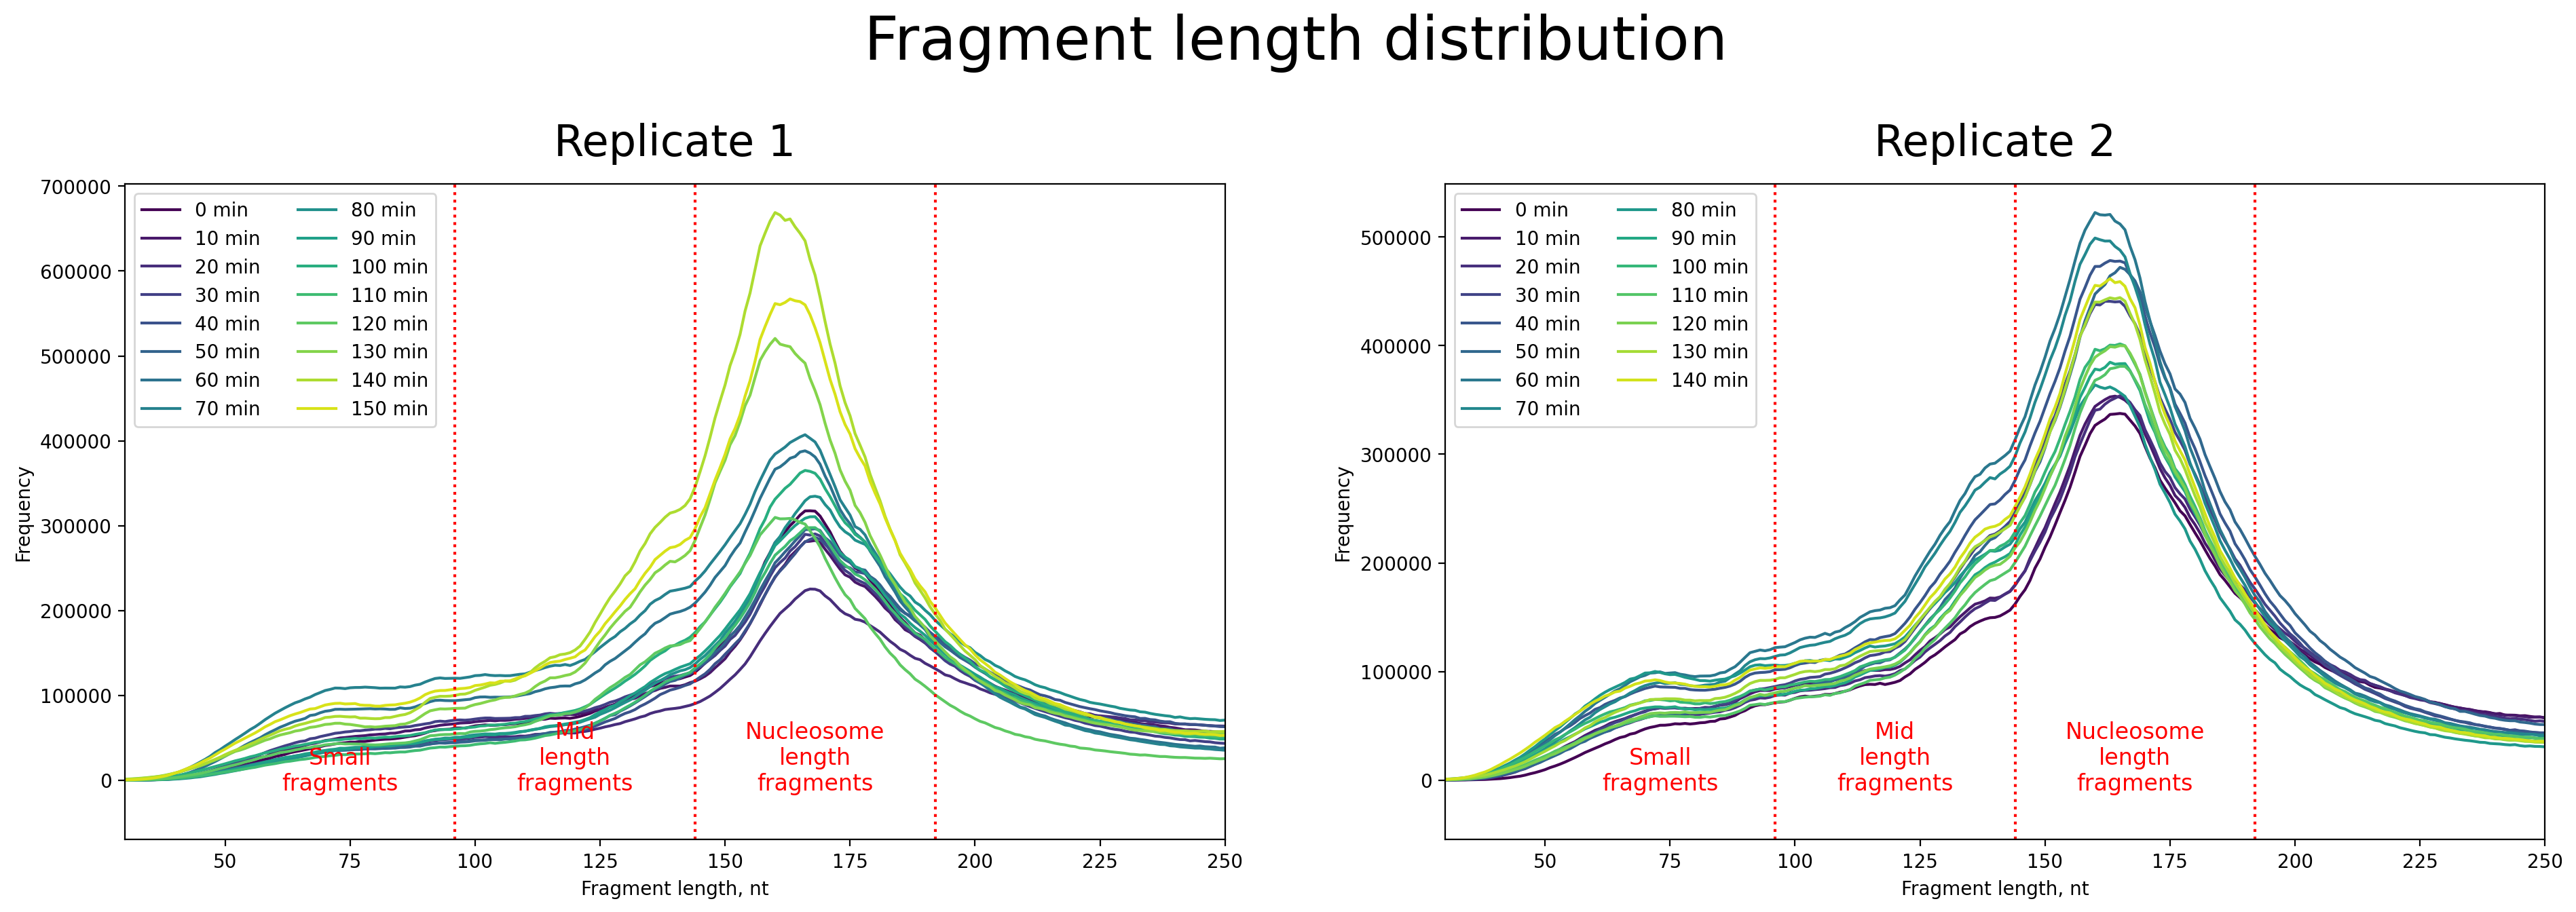

In [6]:
plot_rep_tp_counts(rep1_total_counts_df, rep2_total_counts_df)

In [59]:
joined_replicate_len_counts = rep1_total_counts_df.join(rep2_total_counts_df, 
    lsuffix='_replicate1', rsuffix='_replicate2')
joined_replicate_len_counts = joined_replicate_len_counts.rename(columns={150: '150_replicate1'})

In [135]:
joined_scaling_mat = compute_scaling_matrix(joined_replicate_len_counts)

In [138]:
# Compute the scaling matrix such that the assuemd mean of the timepoints
# being multiplied against will mean to 1

# First divide by the input means
len_counts_mean_1 = joined_replicate_len_counts/joined_replicate_len_counts.mean().mean()
(len_counts_mean_1*joined_scaling_mat).mean(axis=0)


0_replicate1      1.0
10_replicate1     1.0
20_replicate1     1.0
30_replicate1     1.0
40_replicate1     1.0
50_replicate1     1.0
60_replicate1     1.0
70_replicate1     1.0
80_replicate1     1.0
90_replicate1     1.0
100_replicate1    1.0
110_replicate1    1.0
120_replicate1    1.0
130_replicate1    1.0
140_replicate1    1.0
150_replicate1    1.0
0_replicate2      1.0
10_replicate2     1.0
20_replicate2     1.0
30_replicate2     1.0
40_replicate2     1.0
50_replicate2     1.0
60_replicate2     1.0
70_replicate2     1.0
80_replicate2     1.0
90_replicate2     1.0
100_replicate2    1.0
110_replicate2    1.0
120_replicate2    1.0
130_replicate2    1.0
140_replicate2    1.0
dtype: float64

In [139]:
jointed_rescaled_len_counts = (joined_replicate_len_counts * joined_scaling_mat)
jointed_rescaled_len_counts.mean(axis=0)

0_replicate1      107937.305231
10_replicate1     107937.305231
20_replicate1     107937.305231
30_replicate1     107937.305231
40_replicate1     107937.305231
50_replicate1     107937.305231
60_replicate1     107937.305231
70_replicate1     107937.305231
80_replicate1     107937.305231
90_replicate1     107937.305231
100_replicate1    107937.305231
110_replicate1    107937.305231
120_replicate1    107937.305231
130_replicate1    107937.305231
140_replicate1    107937.305231
150_replicate1    107937.305231
0_replicate2      107937.305231
10_replicate2     107937.305231
20_replicate2     107937.305231
30_replicate2     107937.305231
40_replicate2     107937.305231
50_replicate2     107937.305231
60_replicate2     107937.305231
70_replicate2     107937.305231
80_replicate2     107937.305231
90_replicate2     107937.305231
100_replicate2    107937.305231
110_replicate2    107937.305231
120_replicate2    107937.305231
130_replicate2    107937.305231
140_replicate2    107937.305231
dtype: f

In [140]:
joined_scaling_mat.index.name = 'length'

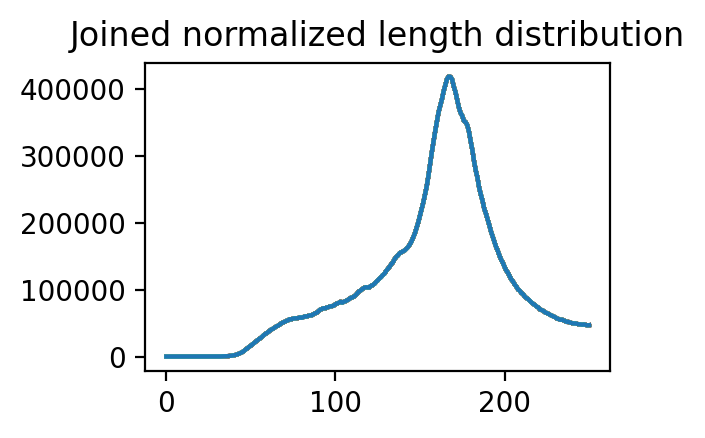

In [141]:
plt.figure(figsize=(3, 2))
plt.plot(jointed_rescaled_len_counts)
plt.title("Joined normalized length distribution")

joined_scaling_mat.to_csv('datasets/computed_mnase/combined_len_scaling.csv')

In [142]:
def get_rep_scaling_mat_from_joined(joined_scaling_mat, replicate):
    joined_scaling_mat.columns[joined_scaling_mat.columns.str.endswith(
        f'_replicate{replicate}')]
    joined_rep1_scaling_mat = joined_scaling_mat[joined_scaling_mat.columns[
        joined_scaling_mat.columns.str.endswith(f'_replicate{replicate}')]]
    joined_rep1_scaling_mat.columns = joined_rep1_scaling_mat.columns.str.replace(
        f'_replicate{replicate}', '').astype(int)
    return joined_rep1_scaling_mat

# Get the specific scaling mats for each replicate so they can be multiplied against
# the raw data
joined_rep1_scaling_mat = get_rep_scaling_mat_from_joined(joined_scaling_mat, 1)
joined_rep2_scaling_mat = get_rep_scaling_mat_from_joined(joined_scaling_mat, 2)


In [144]:
normalized1 = rep1_total_counts_df * joined_rep1_scaling_mat
normalized2 = rep2_total_counts_df * joined_rep2_scaling_mat

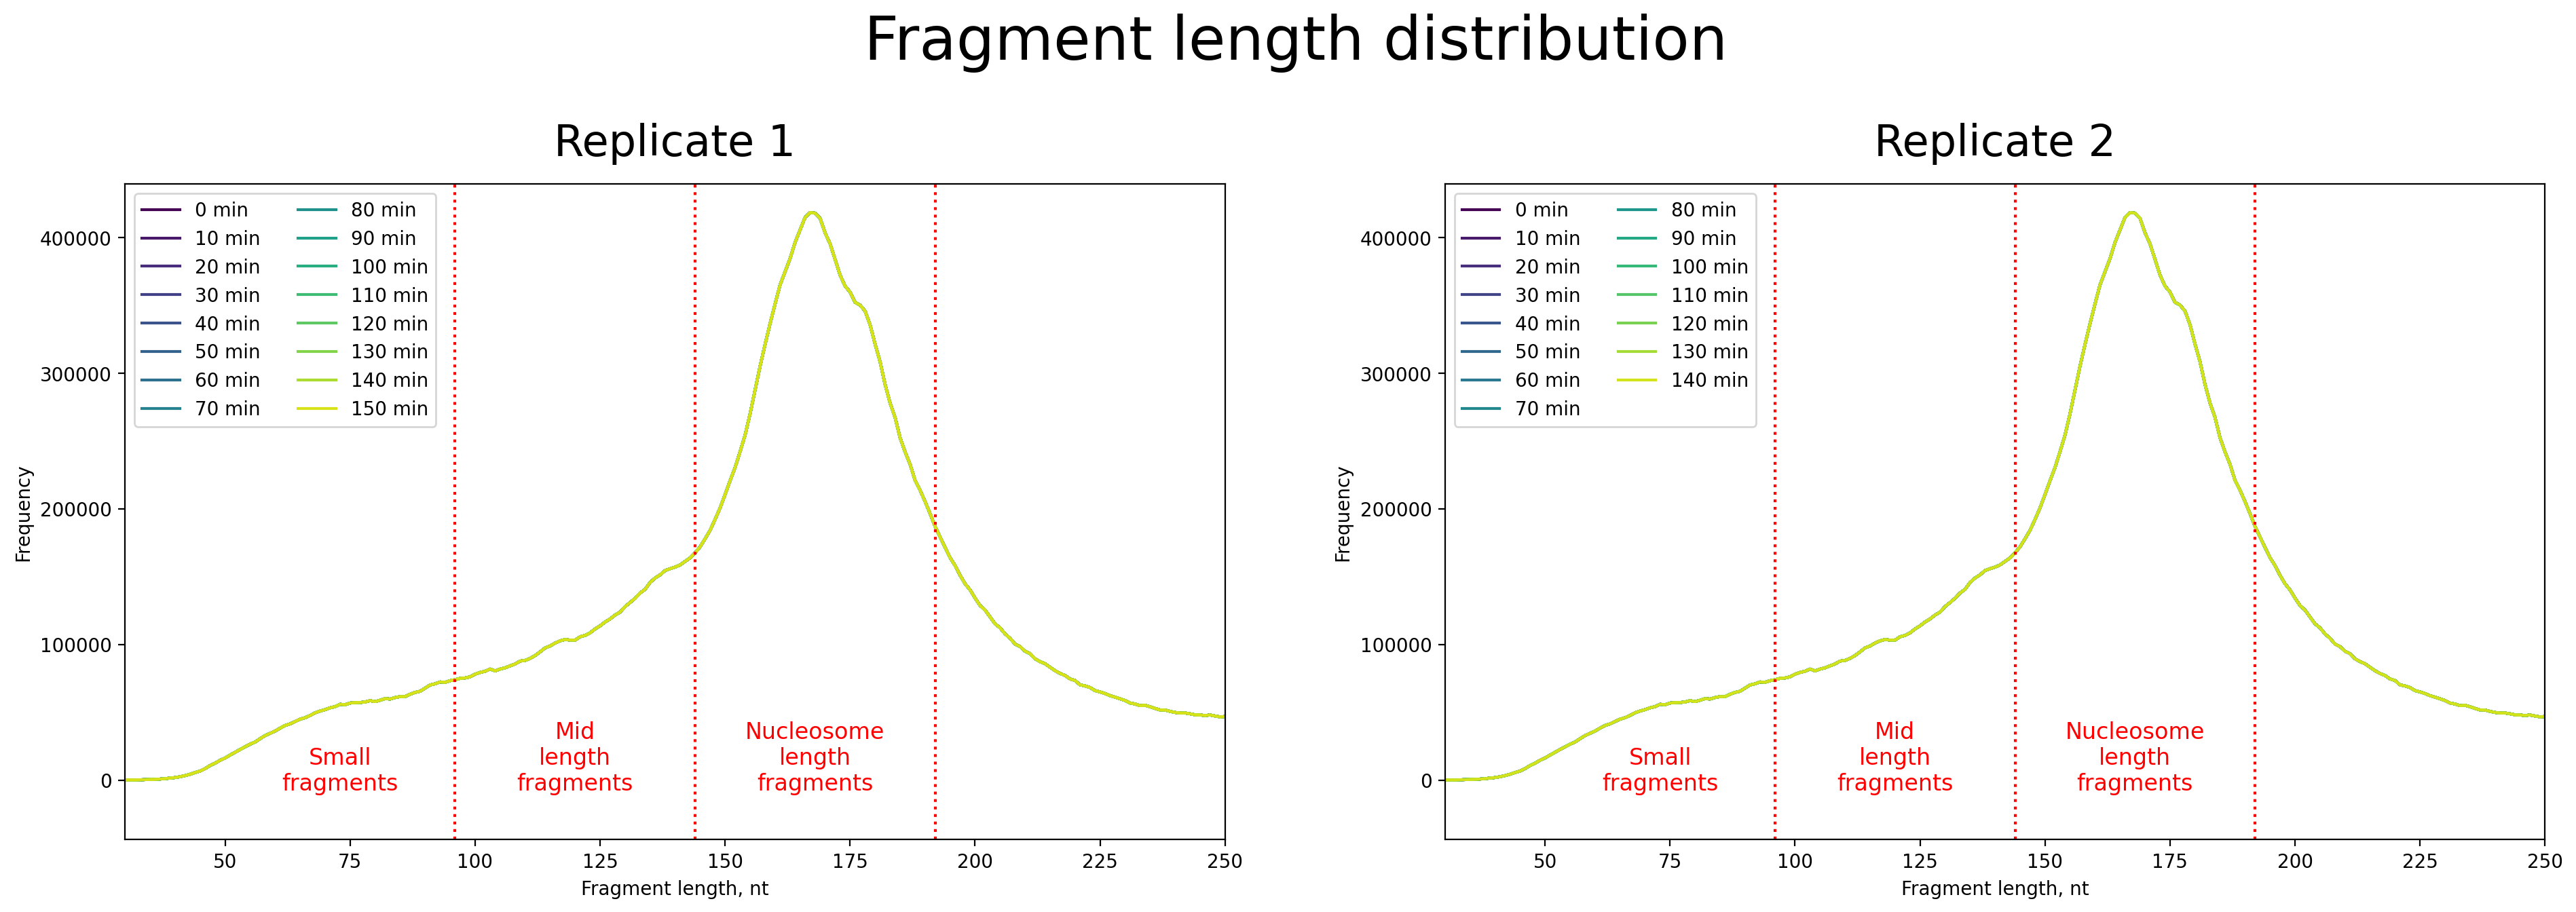

In [145]:
plot_rep_tp_counts(normalized1, normalized2)

In [146]:
pd.read_csv('datasets/computed_mnase/combined_len_scaling.csv')

,length,0_replicate1,10_replicate1,20_replicate1,30_replicate1,40_replicate1,50_replicate1,60_replicate1,70_replicate1,80_replicate1,...,50_replicate2,60_replicate2,70_replicate2,80_replicate2,90_replicate2,100_replicate2,110_replicate2,120_replicate2,130_replicate2,140_replicate2
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,246,0.826494,0.831038,0.737077,1.049802,0.736598,0.854409,1.208675,1.285466,0.664292,...,0.897309,1.119621,1.128886,1.524253,1.209904,1.288353,1.204151,1.327141,1.333945,1.299572
247,247,0.841607,0.835297,0.746670,1.065469,0.750252,0.863772,1.228957,1.307537,0.672908,...,0.915415,1.131931,1.137508,1.525896,1.223197,1.321027,1.211897,1.331615,1.353804,1.326868
248,248,0.829696,0.828794,0.739957,1.072169,0.742189,0.862010,1.213780,1.310964,0.663825,...,0.915663,1.129552,1.125999,1.521956,1.216092,1.314611,1.221657,1.340074,1.350453,1.325452
249,249,0.824782,0.831948,0.730802,1.070182,0.739658,0.862827,1.241665,1.307827,0.663780,...,0.910947,1.117578,1.143980,1.505948,1.211630,1.306106,1.221852,1.326201,1.337229,1.301731
